In [1]:
from pathlib import Path
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
import scipy.sparse as sp
import numpy as np
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


### Fetch Data and Preprocessing

In [95]:
user_data = Path.cwd() / "userData" / "Mack"
additional_data = Path.cwd() / "general_ledger.csv"
# possible_new_data = pd.read_csv(
#     additional_data,
#     usecols=['Date', 'Location', 'Tag1', 'Credit', 'Debit', 'Source', 'E_Transfer'],
#     parse_dates=['Date']
# )
# rawData = pd.read_csv(
#     user_data / "GL2.csv", 
#     usecols=['Date', 'Location', 'Tag1', 'Credit', 'Debit', 'Source', 'E_Transfer'],
#     parse_dates=['Date']
# )
# # X = rawData
# rawData['Tag1'] = rawData['Tag1'].replace('Transfer from Fixed Expense Storage', 'Transfer from Fixed Expenses')
# rawData['Tag1'] = rawData['Tag1'].replace('Transfer to Fixed Expense Storage', 'Transfer to Fixed Expenses')
# X = pd.concat([possible_new_data, rawData])
X = pd.read_csv(
    user_data / 'GL_1lvl.csv',
    usecols=['Date', 'Location', 'Tag1', 'Credit', 'Debit', 'Source','Balance', 'E_Transfer'],
    parse_dates=['Date']
    )


This is the point where X can replace the existing GL. I should test on this new GL to make sure I've got no erros. 
Below here is what should go in the new module

In [96]:
X.shape

(1656, 8)

In [97]:
X['Tag2'] = X['Tag1']
def update_column(
    df: pd.DataFrame, mapping: dict, col_a="A", col_b="B"
) -> pd.DataFrame:
    """Replaces values in col_b based on a mapping dictionary applied to col_a.
    Weak function, modifies df in place"""
    df[col_b] = df[col_a].map(mapping).fillna(df[col_b])
    return df

mapping_dict = {
    "Internet": "Home", 
    "Rent/Internet": "Home",
    "Rent": "Home",
    "Tenant Insurance": "Home",
    "Snack": "Food", 
    "Gas": "Car",
    "Parking": "Car",
    "Car Insurance": "Car",
    "Car Maintenance": "Car",
    "Phone": "Personal",
    "Student Loan": "Personal",
    "Fees": "Finance",
    "Investment": "Finance",
    "Transfer from Mom": "Finance",
    "Transfer to Mom": "Finance",
    "Investment Saving": "Finance",
    "Spotify": "Entertainment",
    "Crave": "Entertainment",
    "Bike Maintenance": "Spending",
    "Bike Maintence": "Spending",
    "Transfer to Credit Card": "Transfer to",
    "Transfer to Chequing": "Transfer to",
    "Transfer from Chequing": "Transfer from",
    "Transfer from Cash Savings": "Transfer from",
    "Transfer from Fixed Expenses": "Transfer from",
    "Transfer to Fixed Expenses": "Transfer to",
    "Transfer to Cash Savings": "Transfer to",
    "Transfer from Mack and Mom Joint": "Transfer from",
    "Transfer to Mack and Mom Joint": "Transfer to",
    "Hydro":"Home",
    "Tuition":"Personal",
    "Misc Bills": "Home",
    "Fixed":"Home",
}

df = update_column(X, mapping_dict, col_a="Tag2", col_b="Tag1")
df.to_csv(user_data / "GL_2lvl.csv", index=False)

In [98]:
X.head()

,Date,Location,Credit,Debit,Balance,Tag1,E_Transfer,Source,Tag2
0,2022-07-05,#208 MARK'S,283.49,0.00,0.0,Spending,0,3635,Spending
1,2022-07-05,REXALL PHARMACY #7126,5.02,0.00,0.0,Spending,0,3635,Spending
2,2022-07-05,CANADA EI,0.00,4284.00,0.0,Income,0,9939,Income
3,2022-07-05,CANADA FPT,0.00,165.12,0.0,Income,0,9939,Income
4,2022-07-06,TELUS COMM. WEB,99.68,0.00,0.0,Home,0,3635,Internet


In [99]:
X['Tag1'].unique()

<StringArray>
[     'Spending',        'Income',          'Home',          'Food',
 'Transfer from',   'Transfer to',      'Personal',           'Car',
       'Finance', 'Entertainment',        'Health']
Length: 11, dtype: str

### Reshaping

In [100]:
X['month'] = X['Date'].dt.month
X['day'] = X['Date'].dt.day
X['Tag1'], budgetLabels = pd.factorize(X['Tag1'])
X['locationLength'] = X['Location'].str.len()
X['Credit'] = X['Credit'].fillna(0).clip(lower=0)
X['Debit']  = X['Debit'].fillna(0).clip(lower=0)

### Split into test and train

In [101]:
X_train, X_test, y_train, y_test = train_test_split(
    X, X['Tag1'], test_size=0.2, random_state=42
)

### Normalization

In [102]:
def norm(df, tfidf, scaler_debit, scaler_credit, dummy_cols=None, mode='train'):
    if mode == 'train':
        df_tfidf = tfidf.fit_transform(df['Location'])
        df['Credit'] = scaler_debit.fit_transform(np.log1p(df[['Credit']]))
        df['Debit']  = scaler_credit.fit_transform(np.log1p(df[['Debit']]))
        df = pd.get_dummies(df, columns=['Source', 'E_Transfer'], prefix=['src', 'etrf'])
        dummy_cols = [c for c in df.columns if c.startswith('src_') or c.startswith('etrf_')]
    else:
        df_tfidf = tfidf.transform(df['Location'])
        df['Credit'] = scaler_debit.transform(np.log1p(df[['Credit']]))
        df['Debit']  = scaler_credit.transform(np.log1p(df[['Debit']]))
        # encode test, then align to train's columns
        df = pd.get_dummies(df, columns=['Source', 'E_Transfer'], prefix=['src', 'etrf'])
        for col in dummy_cols:
            if col not in df.columns:
                df[col] = False   

    df['monthSin'] = np.sin(2 * np.pi * df['Date'].dt.month / 12)
    df['monthCos'] = np.cos(2 * np.pi * df['Date'].dt.month / 12)
    df['daySin']   = np.sin(2 * np.pi * df['Date'].dt.day / 31)
    df['dayCos']   = np.cos(2 * np.pi * df['Date'].dt.day / 31)
    df['locationLength'] = df['Location'].str.len()

    dense_cols = dummy_cols + ['Credit', 'Debit', 'monthSin', 'monthCos', 
                                    'daySin', 'dayCos', 'locationLength']
    dense = df.reindex(columns=dense_cols, fill_value=False)
    combined = sp.hstack([df_tfidf, sp.csr_matrix(dense.astype('float64'))])
    ##For use in control test
    # combined = sp.csr_matrix(dense.astype('float64'))
    return combined, scaler_debit, scaler_credit, dummy_cols

In [103]:
#Shingle and TF-IDF. Fall back on shingle and hash if I need to deploy without a vocab.
#Regular TF-IDF would be better for the class project because of the explainability. 
tfidf = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(5,6),
    min_df=1,
    max_features=5000,
    sublinear_tf=True,
)
scaler_debit = StandardScaler()
scaler_credit = StandardScaler()

XTrainNormalized, scaler_debit, scaler_credit, dummy_cols = norm(X_train, tfidf, scaler_debit, scaler_credit, mode='train')
XTestNormalized,_, _, _  = norm(X_test, tfidf, scaler_debit, scaler_credit, dummy_cols=dummy_cols, mode='test')


In [104]:
X_train.shape

(1324, 12)

In [105]:
XTrainNormalized.get_shape()

(1324, 5044)

### Model Training
Do be expanded for project

In [106]:
model = LogisticRegressionCV(
    #Model Fit Params
    max_iter=1000,
    solver='lbfgs',
    l1_ratios=(0,), 
    tol=1e-4,
    class_weight='balanced',
    #Cross Validation Params
    Cs = 20,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='f1_weighted', #try the "f1_weighted" scoring for my unbalenced classes
    refit=True,
    use_legacy_attributes=False  
)
#Fusion of logistic regression and Cross Validation. Uses a smooth curve as opposed to grid search
##Model Fit
#multinomial is the default now (section 3.2)
#L2 reularization is the default. Chosen with l1_ratios=(0,)
#Choice of solver in Logistic Regression matters to this project. 
#solver{‘lbfgs’, ‘liblinear’, ‘newton-cg’, ‘newton-cholesky’, ‘sag’, ‘saga’}, default=’lbfgs’
# I will need to justify my choice.
#Balanced parameter assists with unbalenced classses.
## Cross Validation
#Use StratifiedKFold because I have a couple classes of 1. 
#Test for 100 values of C (mu)
#3 folds chosen. Some classes have only one value, this minimizes the risk of isolation.
#I will need to justify my choice of scoring method. Accuracy is the default from the course notes
model.fit(XTrainNormalized, y_train)

,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",20
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.","(0,)"
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.See the module :mod:`sklearn.model_selection` module for thelist of possible cross-validation objects... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer dual=False whenn_samples > n_features.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet'}, default='l2'Specify the norm of the penalty:- `'l2'`: add a L2 penalty term (used by default);- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"scoring scoring: str or callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: :ref:`accuracy ` is used.",'f1_weighted'
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' might be slower in :class:`LogisticRegressionCV` because it does not handle warm-starting.- 'liblinear' can only handle binary classification by default. To apply a one-ver

### Evaluation
Tests. We can test any parameter in the model.

In [66]:
import pandas as pd

# 1. Get TF-IDF vocabulary feature names in order
tfidf_feature_names = list(tfidf.get_feature_names_out())

# 2. Recreate the dense feature list in exact order
numeric_cols = ['Credit', 'Debit', 'monthSin', 'monthCos', 'daySin', 'dayCos', 'locationLength']
dense_feature_names = dummy_cols + numeric_cols

# 3. Concatenate to match sp.hstack order
all_feature_names = tfidf_feature_names + dense_feature_names

# 4. Pair feature names with model coefficients
# Assuming model.coef_ is 1D (e.g., binary classification or regression)
coef_df = pd.DataFrame({
    'feature': all_feature_names,
    'coefficient': model.coef_[0].ravel() # .ravel() ensures 1D shape
})
coef_df['magnitude'] = abs(coef_df['coefficient'])
# Display top positive and negative coefficients
print(coef_df.tail(10))

                          feature  coefficient  magnitude
5034       etrf_E_Transfer_Stella     1.170634   1.170634
5035  etrf_E_Transfer_Trent_Bayer     1.532850   1.532850
5036  etrf_E_Transfer_Trevorchung     0.780626   0.780626
5037                       Credit    -0.413892   0.413892
5038                        Debit     0.435648   0.435648
5039                     monthSin    -0.594788   0.594788
5040                     monthCos     0.119834   0.119834
5041                       daySin    -0.872527   0.872527
5042                       dayCos     0.684453   0.684453
5043               locationLength     0.018510   0.018510


In [67]:
print(coef_df.sort_values(by='magnitude', ascending=False).head(50))

                             feature  coefficient  magnitude
666                             fee     -3.182465   3.182465
5000                        src_3635     3.078438   3.078438
5002                        src_4388    -2.951484   2.951484
919                            jw225     2.894377   2.894377
4801                           w225      2.894377   2.894377
3105                          jw225      2.894377   2.894377
3104                           jw225     2.894377   2.894377
918                             jw22     2.894377   2.894377
3094                           jt005     2.765940   2.765940
3095                          jt005      2.765940   2.765940
908                             jt00     2.765940   2.765940
909                            jt005     2.765940   2.765940
4882                           wq111     2.631341   2.631341
4883                          wq111      2.631341   2.631341
3911                           q111      2.631341   2.631341
67                      

In [68]:
print(coef_df.sort_values(by='magnitude', ascending=True).head(25))

     feature  coefficient  magnitude
3162   l2j9l    -0.000352   0.000352
3163  l2j9l2    -0.000352   0.000352
944     l2j9    -0.000352   0.000352
945    l2j9l    -0.000352   0.000352
2172   7w7a2    -0.000449   0.000449
4828   w7a2     -0.000449   0.000449
3960  r7w7a2    -0.000449   0.000449
3959   r7w7a    -0.000449   0.000449
2173  7w7a2     -0.000449   0.000449
4431   t015     -0.000672   0.000672
3317   lt015    -0.000672   0.000672
1019   lt015    -0.000672   0.000672
3318  lt015     -0.000672   0.000672
2166   7l7u6    -0.000806   0.000806
2259  a7l7u6    -0.000806   0.000806
2258   a7l7u    -0.000806   0.000806
3174   l7u6     -0.000806   0.000806
340    a7l7u    -0.000806   0.000806
339     a7l7    -0.000806   0.000806
2167  7l7u6     -0.000806   0.000806
876     jh41    -0.001224   0.001224
877    jh413    -0.001224   0.001224
4638   ui405    -0.001325   0.001325
4639  ui405     -0.001325   0.001325
4929   x231     -0.001378   0.001378


In [107]:
all_possible_labels = list(range(len(budgetLabels)))
y_pred = model.predict(XTestNormalized)
#reveal as df for comparison.
report = pd.DataFrame(
    data = classification_report(
        y_test, 
        y_pred, 
        target_names=budgetLabels, 
        labels=all_possible_labels,
        zero_division=np.nan,
        output_dict=True
    )

)
report.T


,precision,recall,f1-score,support
Spending,0.833333,0.747126,0.787879,87.00000
Income,0.875000,0.875000,0.875000,8.00000
Home,1.000000,0.933333,0.965517,15.00000
Food,0.868687,0.860000,0.864322,100.00000
Transfer from,0.818182,1.000000,0.900000,27.00000
Transfer to,0.970588,1.000000,0.985075,33.00000
Personal,1.000000,1.000000,1.000000,8.00000
Car,0.818182,0.900000,0.857143,30.00000
Finance,0.850000,0.894737,0.871795,19.00000
Entertainment,1.000000,1.000000,1.000000,4.00000


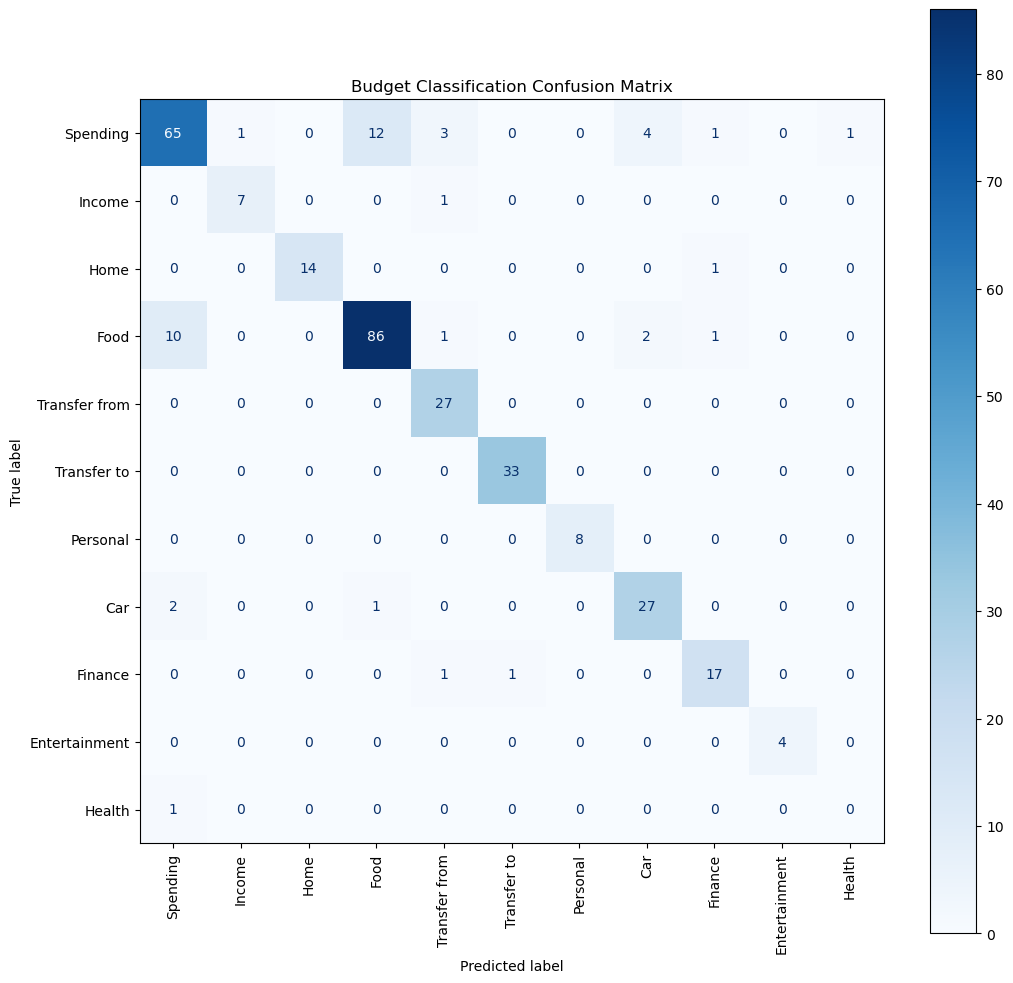

In [108]:

# Increase the figure size so the 31 labels aren't cramped
fig, ax = plt.subplots(figsize=(12, 12))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    labels=all_possible_labels,
    display_labels=budgetLabels,  
    xticks_rotation='vertical',   
    cmap='Blues',                 
    ax=ax,
    colorbar=True
)

plt.title("Budget Classification Confusion Matrix")
plt.show()